In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn



In [2]:
df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Glucose,BloodPressure,SkinThickness,Insulin,BMI is zero in original dataset which is impossible therefore replacing them with theor respective median values

In [7]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in cols:
    df[col] = df[col].replace(0, np.nan)

    df[col] = df.groupby('Outcome')[col].transform(
        lambda x: x.fillna(x.median())
    )

In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<Axes: xlabel='Outcome', ylabel='Count'>

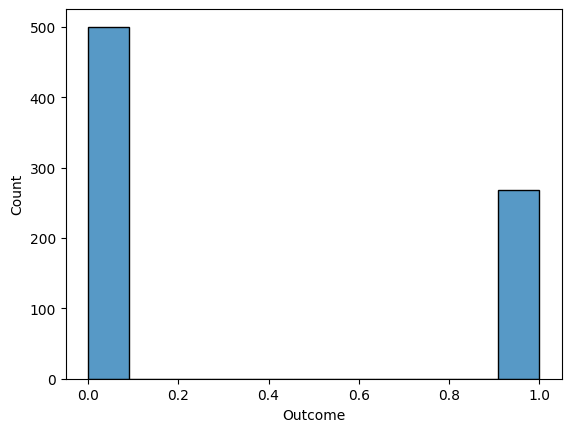

In [9]:
sns.histplot(df["Outcome"])

<Axes: xlabel='Glucose', ylabel='Count'>

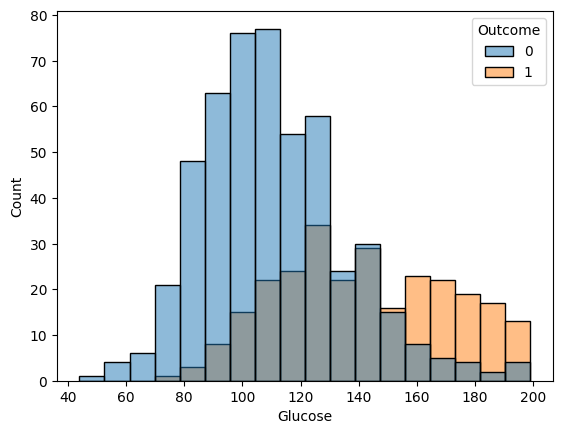

In [10]:
sns.histplot(x="Glucose", hue="Outcome", data=df, kde=False)

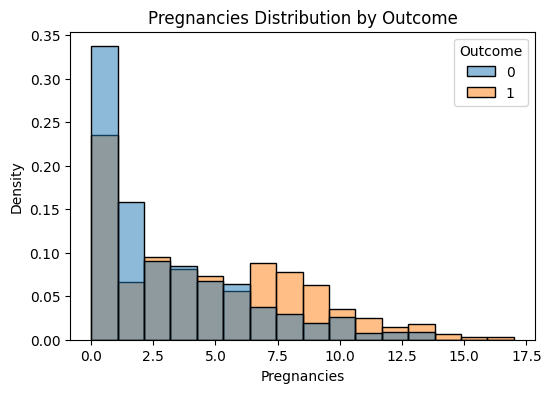

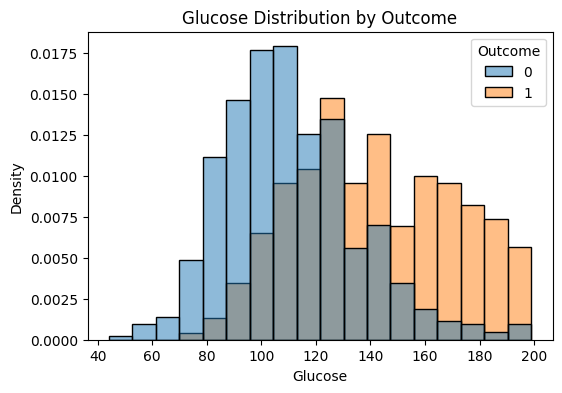

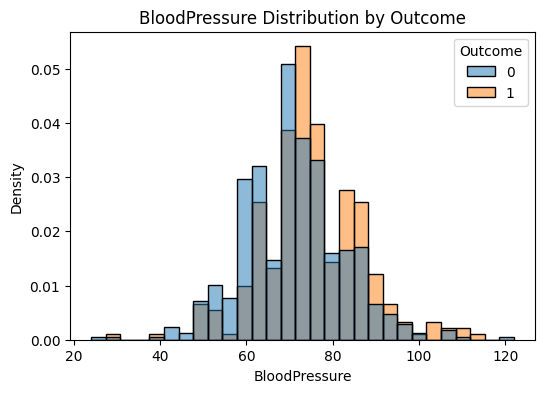

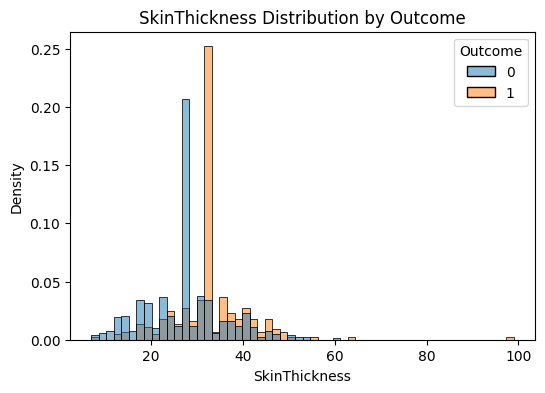

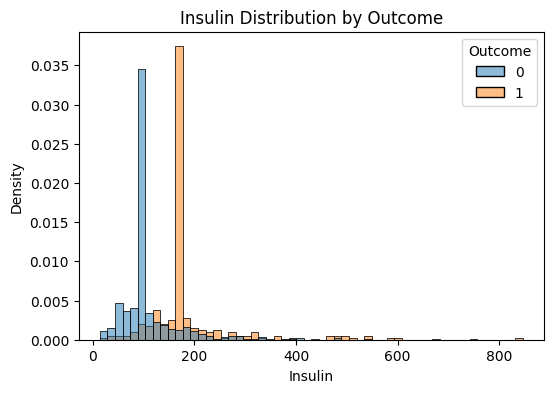

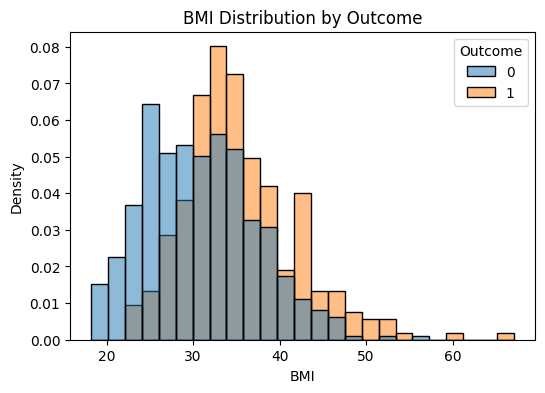

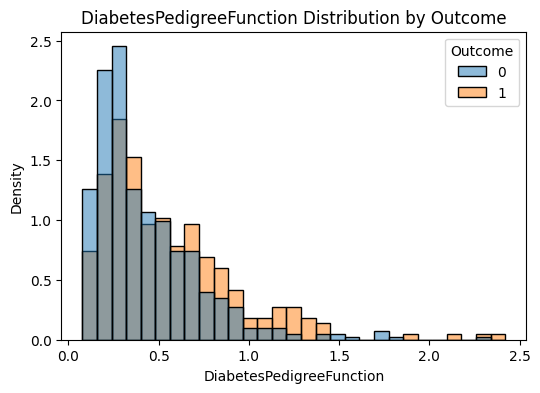

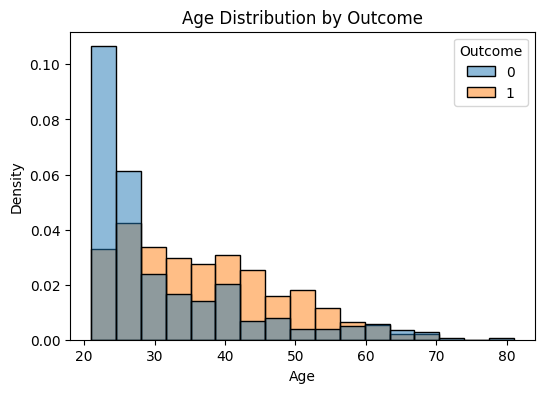

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

features = df.columns[:-1]

for feature in features:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=feature, hue='Outcome',
                 kde=False, stat='density',
                 common_norm=False)
    plt.title(f'{feature} Distribution by Outcome')
    plt.show()

In [12]:
corr_with_diabetes = df.corr()['Outcome'].drop('Outcome').sort_values()

print("Most Positive correlation (strong diabetes signal):")
print(corr_with_diabetes.head(10))


Most Positive correlation (strong diabetes signal):
DiabetesPedigreeFunction    0.173844
BloodPressure               0.174469
Pregnancies                 0.221898
Age                         0.238356
SkinThickness               0.295138
BMI                         0.315577
Insulin                     0.377081
Glucose                     0.495990
Name: Outcome, dtype: float64


### Glusose is the strongest indicator for Diabetes,secondly Insulin and BMI


<Axes: >

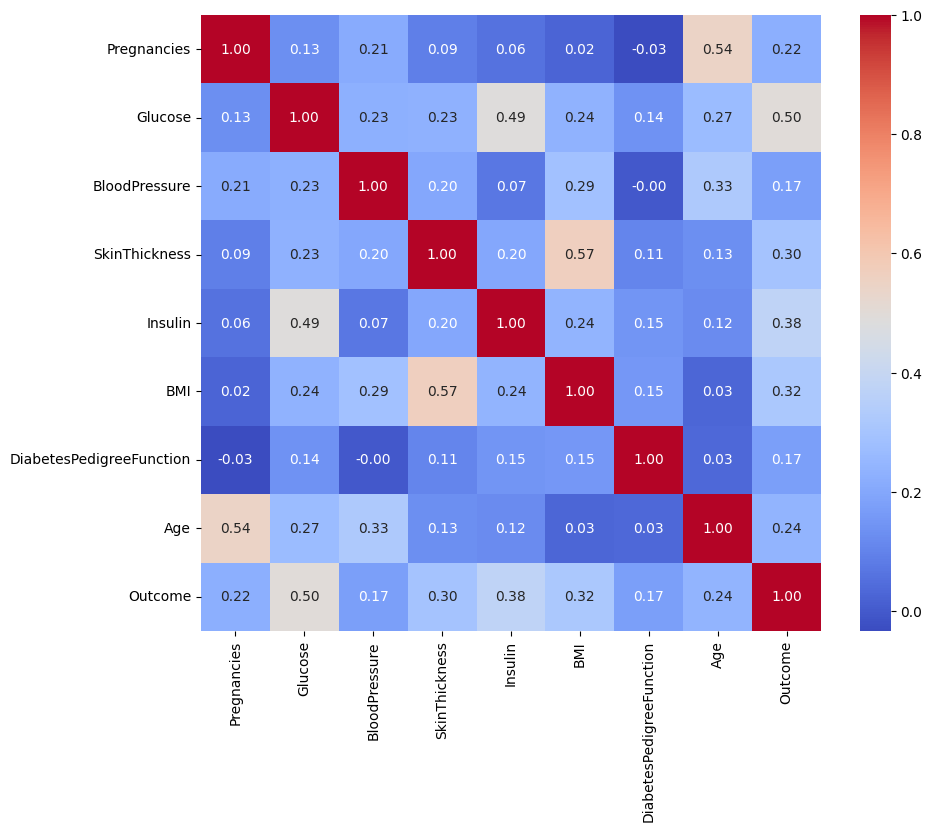

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

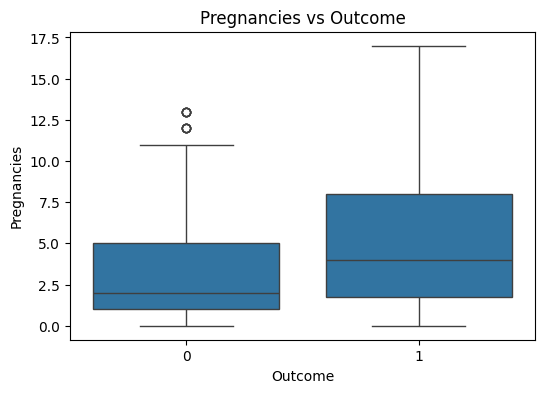

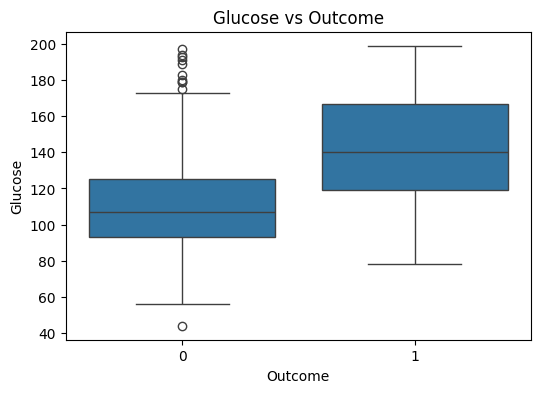

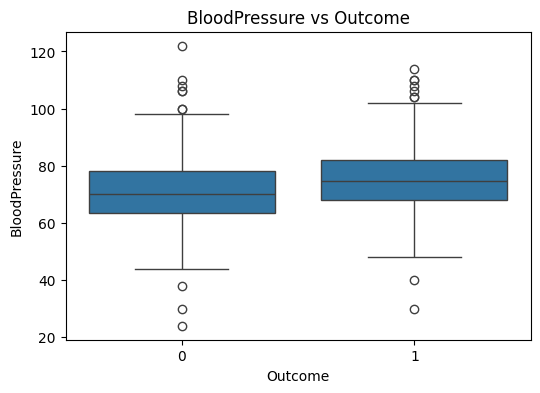

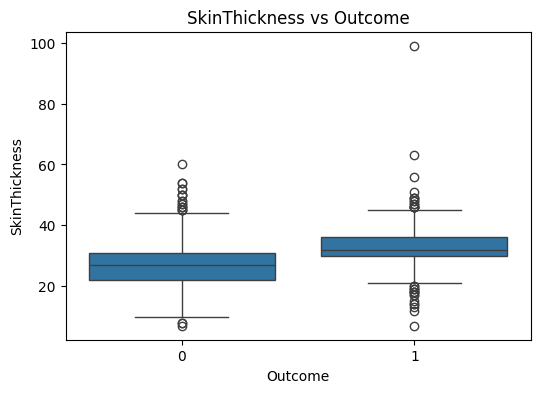

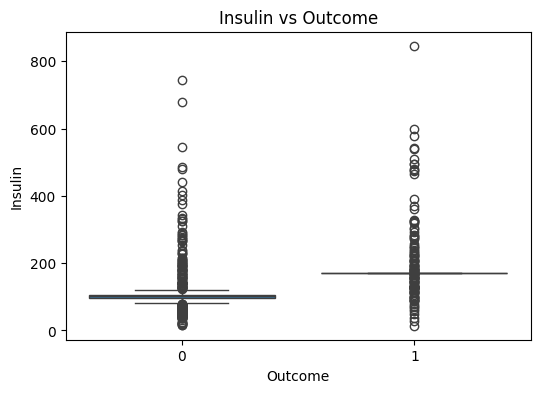

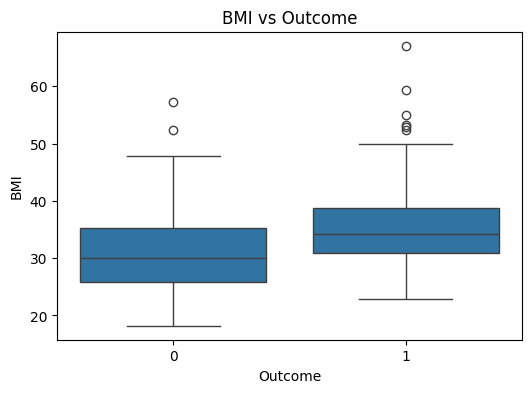

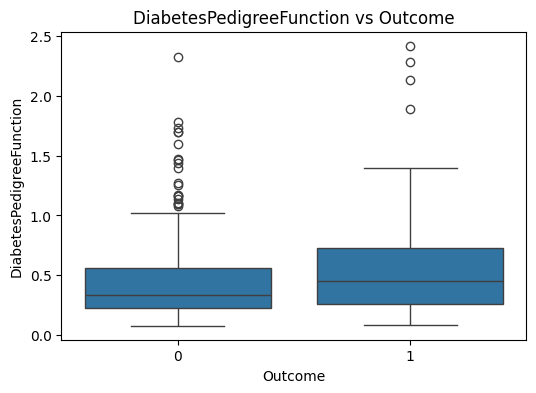

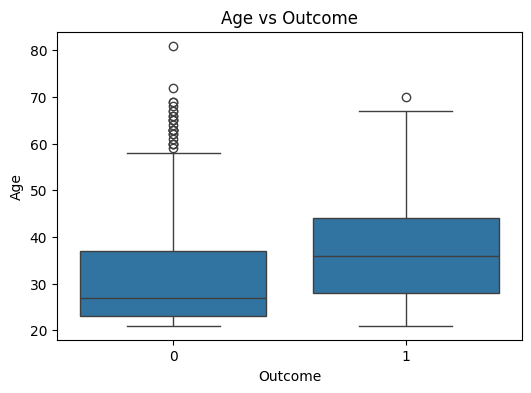

In [14]:
features = df.columns[:-1]

for feature in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Outcome',
                y=feature,
                data=df)
    plt.title(f'{feature} vs Outcome')
    plt.show()

### Feature Engineering-Added two columns BMI_category and Age_group

In [15]:
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df['BMI_Category'] = df['BMI'].apply(bmi_category)

In [16]:
def age_group(age):
    if age < 30:
        return "Young"
    elif age < 50:
        return "Middle-aged"
    else:
        return "Senior"
    
df['Age_Group'] = df['Age'].apply(age_group)

In [17]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Group
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1,Obese,Senior
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0,Overweight,Middle-aged
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1,Normal,Middle-aged
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,Overweight,Young
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,Obese,Middle-aged


In [18]:
df = pd.get_dummies(
    df,
    columns=['BMI_Category', 'Age_Group'],
    drop_first=True
)

In [19]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category_Obese,BMI_Category_Overweight,BMI_Category_Underweight,Age_Group_Senior,Age_Group_Young
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1,True,False,False,True,False
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0,False,True,False,False,False
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1,False,False,False,False,False
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,False,True,False,False,True
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,True,False,False,False,False


In [20]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category_Obese,BMI_Category_Overweight,BMI_Category_Underweight,Age_Group_Senior,Age_Group_Young
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1,1,0,0,1,0
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0,0,1,0,0,0
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1,0,0,0,0,0
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,0,1,0,0,1
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,1,0,0,0,0


In [21]:
X=df.drop(columns=['Outcome'])
y=df['Outcome']

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42, scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()),
    "SVM": SVC(kernel='rbf', random_state=42, class_weight='balanced', probability=True)
}

In [37]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=skf,
        scoring='f1'
    )

    print(
        f"{name}: "
        f"Mean F1 = {scores.mean():.3f}, "
        f"Std = {scores.std():.3f}"
    )

Logistic Regression: Mean F1 = 0.738, Std = 0.037
Random Forest: Mean F1 = 0.817, Std = 0.018
XGBoost: Mean F1 = 0.813, Std = 0.025
SVM: Mean F1 = 0.764, Std = 0.026


### Random Forest works best here.To further confirm which is best model applying hyperparameter tuning to XGBoost

In [38]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

search = RandomizedSearchCV(
    XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ),
    param_grid,
    scoring='f1',
    cv=5,
    n_iter=20,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

print(search.best_params_)
print(search.best_score_)

{'subsample': 1.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
0.8411342103202568


### So final model is XGBoost

In [39]:
final_xgb=XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bytree=1.0,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
)
final_xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [41]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)

y_pred = final_xgb.predict(X_test)
y_prob = final_xgb.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))

print("F1:", f1_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.91      0.89      0.90       100
           1       0.80      0.83      0.82        54

    accuracy                           0.87       154
   macro avg       0.86      0.86      0.86       154
weighted avg       0.87      0.87      0.87       154

F1: 0.8181818181818182
Precision: 0.8035714285714286
Recall: 0.8333333333333334
ROC-AUC: 0.9518518518518518


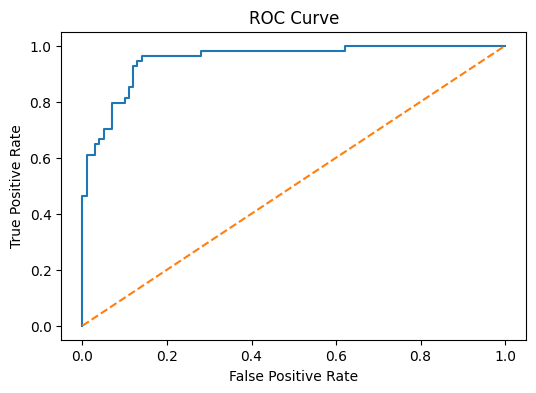

In [42]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

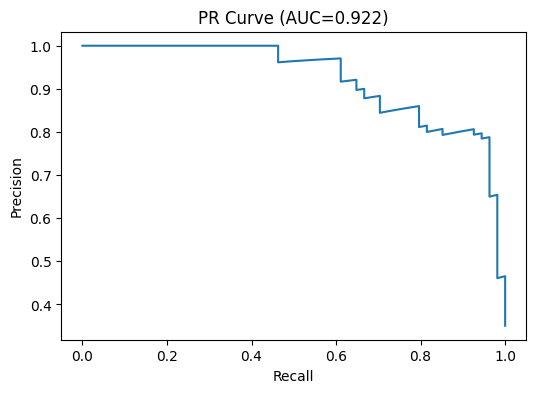

In [43]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(
    y_test,
    y_prob
)

pr_auc = auc(recall, precision)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"PR Curve (AUC={pr_auc:.3f})")
plt.show()

### Shap Explainability

e:\ML_PROJECTS\Diabetes_Detection_Model\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


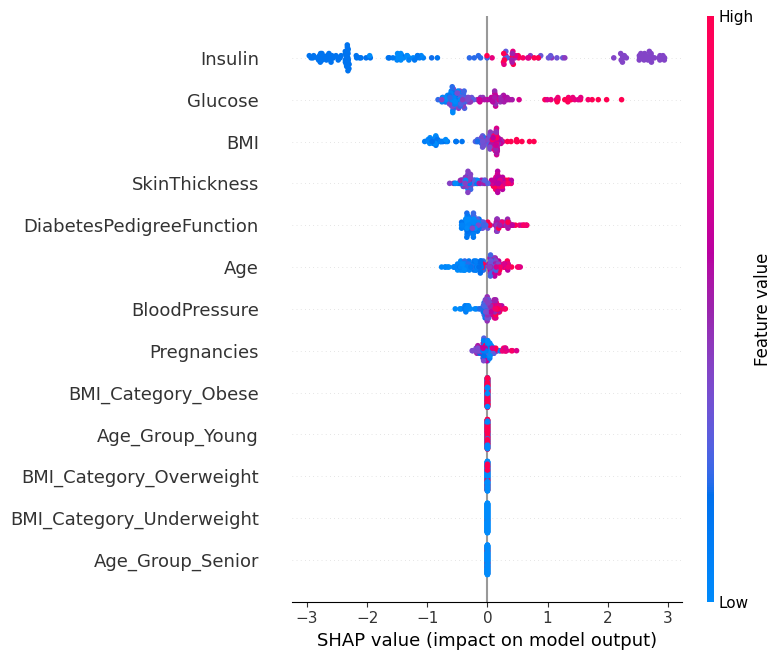

In [44]:
import shap

explainer = shap.TreeExplainer(final_xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

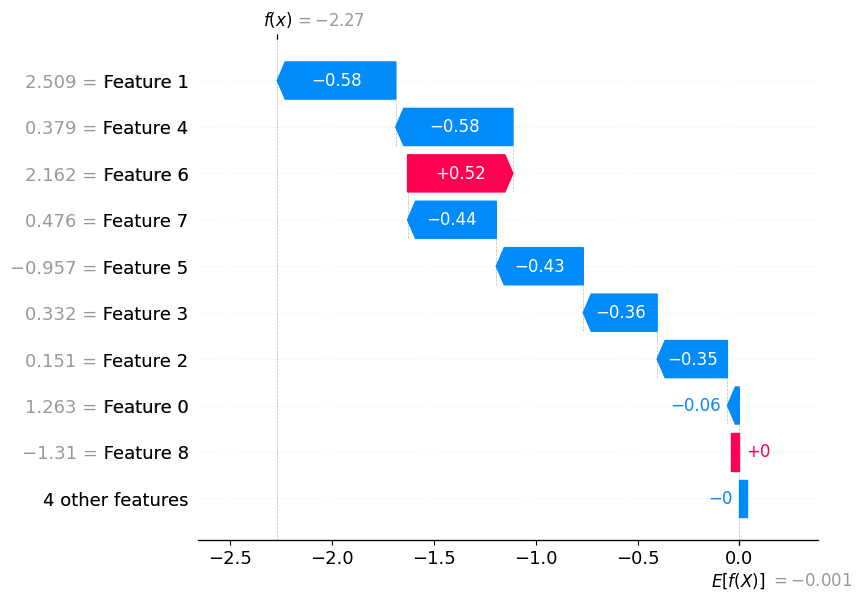

In [49]:

y_prob = final_xgb.predict_proba(X_test_scaled)[:, 1]
patient_idx = np.argmax(y_prob)

explainer = shap.TreeExplainer(final_xgb)

shap_values = explainer(X_test_scaled)
shap.plots.waterfall(
    shap_values[patient_idx],
    max_display=10
)

In [50]:
import joblib
joblib.dump(final_xgb, "diabetes_xgb_model.pkl")

['diabetes_xgb_model.pkl']